In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os
from pysuto.util import get_path

figp = r'/mnt/nfs_fineprint/tmp/PYSUT/pySUTO/figs/ex'


colors = {
    'United States':  '#457B9D',  # steel blue
    'Chile':          '#2A9D8F',  # teal
    'China':          '#E76F51',  # muted red
    'Peru':           '#E9C46A',  # warm yellow
    'Australia':      '#F4A261',  # soft orange
    'Brazil':         '#52B788',  # sage green
    'Argentina':      '#3D9970',  # deeper green
    'Zambia':         '#A44A3F',  # deep brick red
    'Poland':         '#8D99AE',  # cool gray blue
    'Russia':         '#3D5A80',  # dark navy blue
    'Kazakhstan':     '#B5838D',  # dusty rose
    'Mexico':         '#C9A84C',  # golden ochre
    'Germany':        '#6B8F71',  # muted olive green
    'Japan':          '#264653',  # deep blue-green
    'Canada':         '#81B29A',  # muted mint
    'Congo, D.R.':    '#6A4C93',  # muted purple
    'Colombia':       '#2B9EB3',  # cerulean
    'India':          '#F28C38',  # burnt orange
    'South Korea':    '#9B5DE5',  # medium purple
    'Rest of World':  '#D9D9D9',  # light gray
}

# Region identification for model ~30

In [99]:
p=r'/mnt/nfs_fineprint/tmp/PYSUT/pySUTO/data/proc/datafeed/icsg_clean/icsg_flows.csv'

f = pd.read_csv(p)
f

,Region,Type,Year,Value,Process,Supply_Use,Unit,Year_loaded_from_file
0,Indonesia,Concentrates,1996,525.7000,Mining,Supply,kt,2005
1,Iran,Concentrates,1996,103.0000,Mining,Supply,kt,2005
2,Japan,Concentrates,1996,1.1000,Mining,Supply,kt,2005
3,Kazakhstan,Concentrates,1996,250.2000,Mining,Supply,kt,2005
4,North Macedonia,Concentrates,1996,13.5000,Mining,Supply,kt,2005
...,...,...,...,...,...,...,...,...
7875,Italy,Copper Alloy,2022,681.8999,Semi,Supply,kt,2025
7876,Japan,Copper,2022,970.0000,Semi,Supply,kt,2025
7877,Japan,Copper Alloy,2022,342.0000,Semi,Supply,kt,2025
7878,South Korea,Copper,2022,638.6460,Semi,Supply,kt,2025


In [100]:
# df = your dataframe

# Step 1: get top 30 regions per Type based on Value
top30_per_type = (
    f.sort_values('Value', ascending=False)
      .groupby(['Type', 'Year'])
      .head(10)
)

# Step 2: get unique regions from these selections
unique_regions = top30_per_type['Region'].unique()

# Optional: convert to list
unique_regions_list = list(unique_regions)

stock_regions = ['United States', 'Chile', 'China', 'Germany', 'Japan', 'Taiwan', 'Singapore', 'Malaysia', 'South Korea', 'Spain', 'Iran', 'Belgium', 'Netherlands', 'United Arab Emirates', 'France', 'Brazil', 'United Kingdom', 'Sweden', 'Italy', 'Poland', 'Zambia', 'Canada', 'Peru', 'South Africa', 'Australia', 'Philippines', 'Scandinavia', 'India', 'Bulgaria', 'Slovakia', 'Greece']

# combine and deduplicate
combined_regions = set(unique_regions_list) | set(stock_regions)
# convert back to sorted list
final_regions = sorted(combined_regions)
final_regions
len(final_regions)

41

In [101]:
print(final_regions)

['Australia', 'Austria', 'Belgium', 'Belgium-Luxembourg', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Congo, D.R.', 'France', 'Germany', 'Greece', 'India', 'Indonesia', 'Iran', 'Italy', 'Japan', 'Kazakhstan', 'Luxembourg', 'Malaysia', 'Mexico', 'Netherlands', 'Peru', 'Philippines', 'Poland', 'Russia', 'Scandinavia', 'Singapore', 'Slovakia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Taiwan', 'United Arab Emirates', 'United Kingdom', 'United States', 'Zambia']


In [102]:
len(f.Region.unique(
    
))

91

In [103]:
print(sorted(f.Region.unique()))


['Albania', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Belgium-Luxembourg', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Congo Rep.', 'Congo, D.R.', 'Croatia', 'Cuba', 'Cyprus', 'Czech Rep.', 'Denmark', 'Dominican Rep.', 'Ecuador', 'Egypt', 'Eritrea', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Honduras', 'Hungary', 'India', 'Indonesia', 'Iran', 'Italy', 'Japan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Luxembourg', 'Malaysia', 'Mauritania', 'Mexico', 'Mongolia', 'Morocco', 'Myanmar', 'Namibia', 'Netherlands', 'New Zealand', 'North Korea', 'North Macedonia', 'Norway', 'Oman', 'Pakistan', 'Panama', 'Papua New Guinea', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Scandinavia', 'Serbia', 'Serbia and Montenegro', 'Singapore', 'Slovakia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Taiwan', 'Tanzania', 'Thailand', 'Turkey', 'Ukraine',

In [104]:
def plot_region_share(f, var, colors, c_select, ax=None):
    # -------------------------------------------------
    # 1. Filter & aggregate
    # -------------------------------------------------
    d = f[f['Type'] == var].copy()

    data = d.groupby(['Year', 'Region'])['Value'].sum().reset_index()
    total = data.groupby('Year')['Value'].sum().rename('Total')
    data = data.join(total, on='Year')
    data['Share'] = data['Value'] / data['Total']

    # -------------------------------------------------
    # 2. Label Rest of World
    # -------------------------------------------------
    data['Region_plot'] = data['Region'].where(
        data['Region'].isin(c_select), 'Rest of World'
    )
    data = data.groupby(['Year', 'Region_plot'])['Share'].sum().reset_index()

    # -------------------------------------------------
    # 3. Pivot & order
    # -------------------------------------------------
    df_plot = data.pivot(index='Year', columns='Region_plot', values='Share').fillna(0)
    order = [c for c in c_select if c in df_plot.columns] + \
            (['Rest of World'] if 'Rest of World' in df_plot.columns else [])
    df_plot = df_plot[order]

    # -------------------------------------------------
    # 4. Plot
    # -------------------------------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    df_plot.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=[colors.get(c, '#D9D9D9') for c in df_plot.columns],
        edgecolor='none',
        width=0.8,
    )

    ax.set_ylabel('Share of Concentrates')
    ax.set_xlabel('Year')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    
    return ax

# Mining

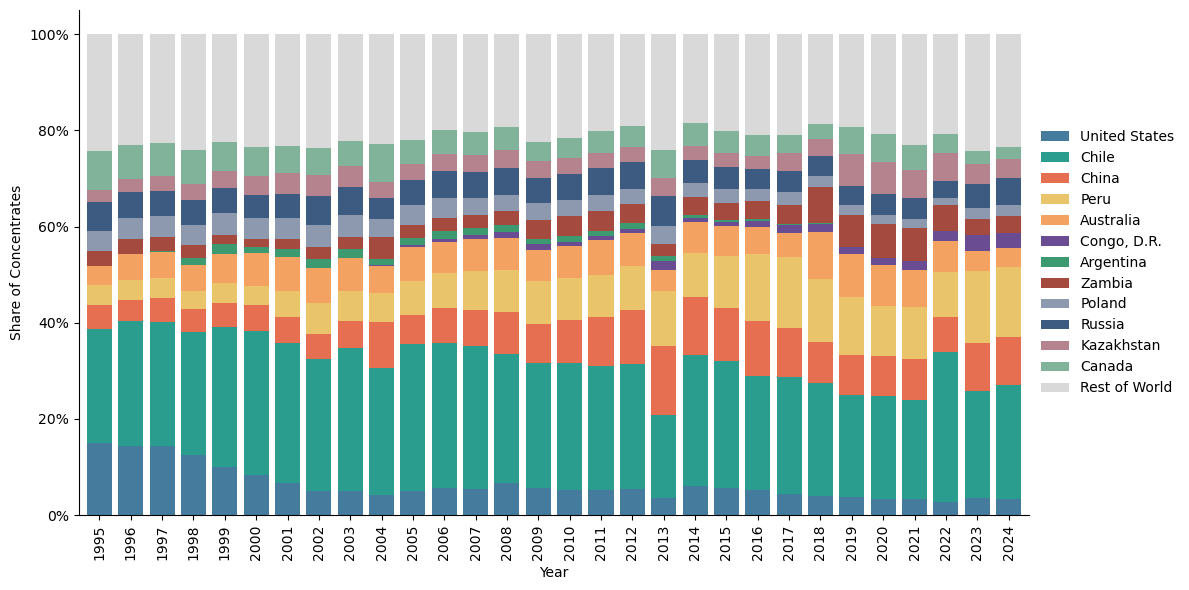

In [105]:
c_select = [
    "United States",
    "Chile",
    "China",
    "Peru",
    "Australia",
    "Congo, D.R.",
    "Argentina",
    "Zambia",
    "Poland",
    "Russia",
    "Kazakhstan",
    "Canada",
]
var = 'Concentrates'
ax = plot_region_share(f, var, colors, c_select)

p = os.path.join(figp, 'concentrates_share.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()

# Smelting

In [106]:
sm = f[f.Process == 'Smelting']
sm

,Region,Type,Year,Value,Process,Supply_Use,Unit,Year_loaded_from_file
311,Austria,Secondary,1995,47.000,Smelting,Supply,kt,2005
312,Belgium,Secondary,1995,149.200,Smelting,Supply,kt,2005
313,Botswana,Primary,1995,22.100,Smelting,Supply,kt,2005
314,Brazil,Primary,1995,165.000,Smelting,Supply,kt,2005
315,Bulgaria,Primary,1995,97.700,Smelting,Supply,kt,2005
...,...,...,...,...,...,...,...,...
6467,Spain,Primary,2024,230.768,Smelting,Supply,kt,2025
6468,Spain,Secondary,2024,16.878,Smelting,Supply,kt,2025
6469,Sweden,Primary,2024,188.510,Smelting,Supply,kt,2025
6470,Sweden,Secondary,2024,80.790,Smelting,Supply,kt,2025


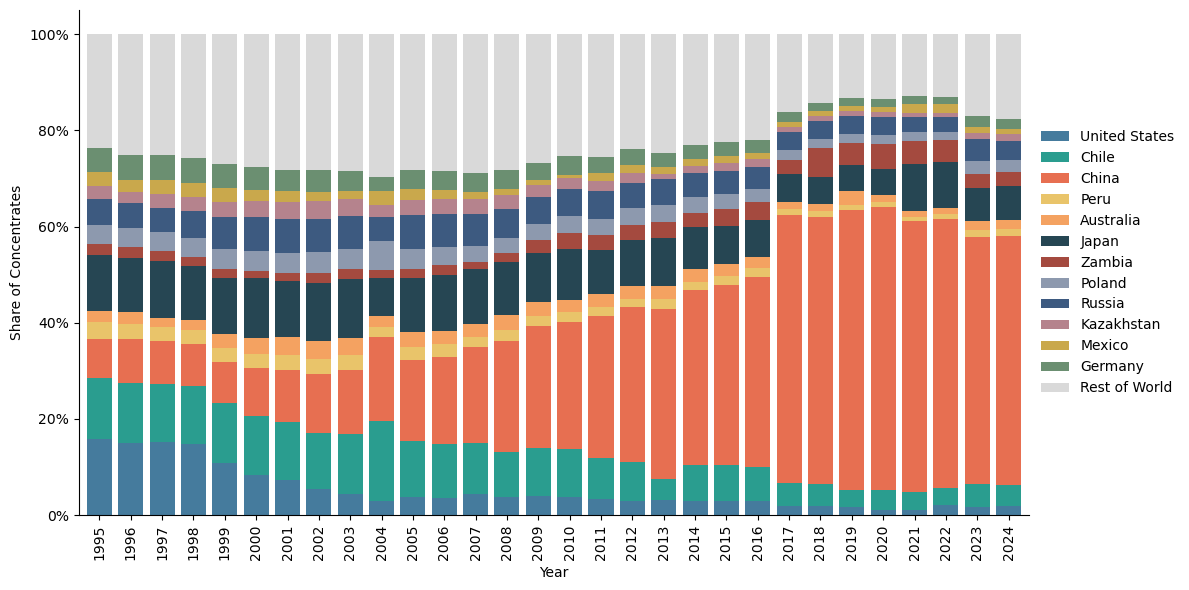

In [107]:
# group
sm_grouped = sm.groupby(['Year', 'Region'])['Value'].sum().reset_index()

sm_grouped['Type'] = 'Matte'

c_select = [
    "United States",
    "Chile",
    "China",
    "Peru",
    "Australia",
    "Japan",
    "Argentina",
    "Zambia",
    "Poland",
    "Russia",
    "Kazakhstan",
    "Mexico",
    "Germany"
]
# plot it
ax = plot_region_share(sm_grouped, 'Matte', colors, c_select)
# save it
p = os.path.join(figp, 'matte_share.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()

In [113]:
# biggest matte countries in 1995
sm_1995 = sm_grouped[sm_grouped['Year'] == 2006]
sm_1995_sorted = sm_1995.sort_values('Value', ascending=False)
print(sm_1995_sorted[['Region', 'Value']].head(10))

            Region   Value
423          China  2517.5
430          Japan  1628.3
422          Chile  1565.4
440         Russia   953.4
427          India   624.6
426        Germany   544.1
439         Poland   525.1
421         Canada   520.5
448  United States   501.3
444    South Korea   484.0


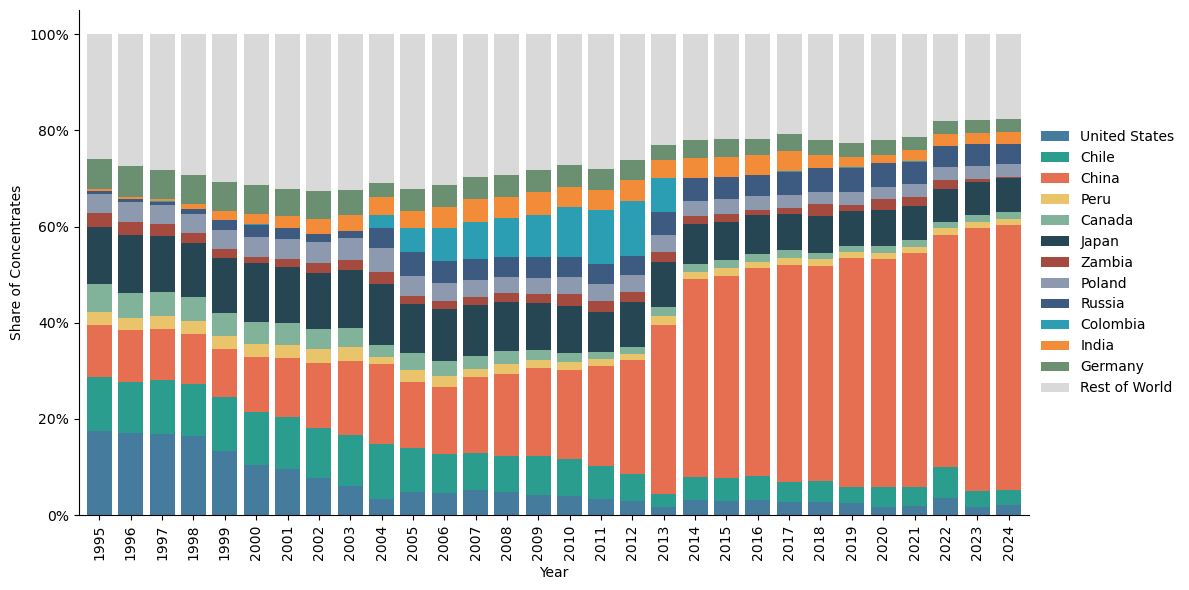

In [109]:
rf = f[f.Process == 'Refining']

grouped = rf.groupby(['Year', 'Region'])['Value'].sum().reset_index()

grouped['Type'] = 'Cathode'

c_select = [
    "United States",
    "Chile",
    "China",
    "Peru",
    "Canada",
    "Japan",

    "Zambia",
    "Poland",
    "Russia",
    "Colombia",
    "India",
    "Germany"
]
# plot it
ax = plot_region_share(grouped, 'Cathode', colors, c_select)
# save it
p = os.path.join(figp, 'matte_share.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()

In [112]:
print(rf[rf.Year == 2007].sort_values('Value', ascending=False)[['Region', 'Value']].head(10))


             Region   Value
3345          China  2345.2
3560          Japan  1369.7
3346       Colombia  1136.0
3296          Chile  1104.4
3739  United States   764.4
3338          India   699.9
3543         Russia   649.3
3563    South Korea   537.0
3541         Poland   493.2
3294         Canada   405.2


# SEMI